# Lab 1 — Polynomial LSMC for an openIRM proxy model

**Lausanne actuarial workshop · 12 August 2026**  
**Mark-Oliver Wolf**  
**Revision 5 · verified 11 August 2026**

**Suggested time:** 15 minutes

In this lab, we will:

1. turn nested-simulation output into regression targets;
2. hand-select a compact set of polynomial interactions with checkboxes;
3. assess $R^2$, $ΔSCR$, fit time, and a complexity-penalized score;
4. contrast the compact model with exhaustive degree-2 and degree-3 bases.

Run the cells in order. Pause in Section 3 to use the controls before continuing to Section 4.


## 1. Load the lab tools and data

To keep the exercise readable, technical code for loading, checking, fitting, evaluating, plotting, and the interactive controls is stored in `wednesday_lab1_utils.py`. You do not need to open or edit that file during the lab.

The notebook itself contains only the modelling choices and the calls that show their results. The external packages remain NumPy, pandas, Matplotlib, scikit-learn, and ipywidgets.


In [1]:
import wednesday_lab1_utils as lab1

data = lab1.load_data()
lab1.data_summary(data)

,quantity,value
0,outer training states,2500.00000
1,risk factors,10.00000
2,inner outcomes per training state,54.00000
3,outer test states,200.00000
4,inner outcomes per test benchmark,10000.00000
5,mean training-target MC standard error (€bn),0.66688
6,mean benchmark MC standard error (€bn),0.05040


## 2. From inner outcomes to conditional-expectation targets

For outer state $X_i$, `train_Z` contains $m=54$ conditionally simulated outcomes

$$Z_{i,1},\ldots,Z_{i,m}.$$

The proxy target is the conditional expectation

$$\mu(x)=\mathbb{E}[Z\mid X=x],$$

estimated at each training state by

$$\bar Z_i=\frac{1}{m}\sum_{j=1}^m Z_{i,j}.$$

Each row of `test_Y` uses 10,000 inner simulations and is therefore much closer to $\mu(X)$ than a training mean. Monetary values are expressed in **billions of euros** for readability and numerical conditioning.


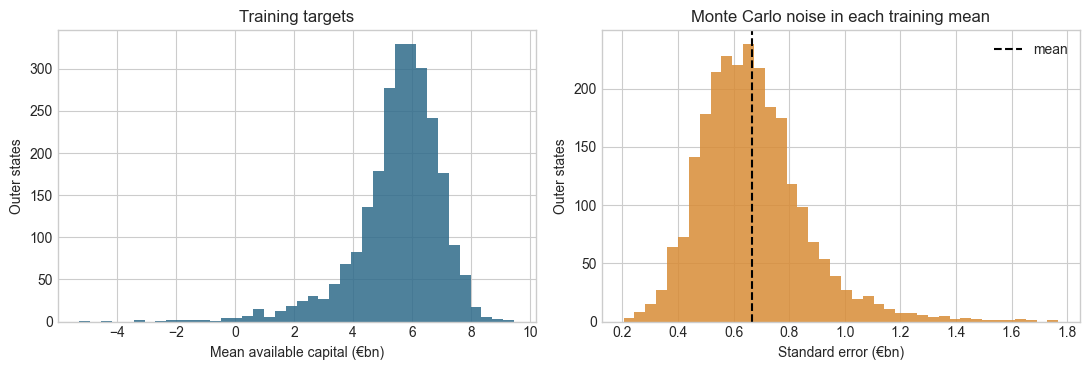

In [2]:
lab1.plot_training_targets(data)


### Why averaging is appropriate here

With the same number $m$ of inner outcomes at every outer state, fitting ordinary least squares to all repeated pairs $(X_i,Z_{i,j})$ gives the same coefficients as fitting to $(X_i,\bar Z_i)$:

$$
\sum_{i=1}^{n}\sum_{j=1}^{m}\bigl(Z_{i,j}-f(X_i)\bigr)^2
= C + m\sum_{i=1}^{n}\bigl(\bar Z_i-f(X_i)\bigr)^2,
$$

where $C$ does not depend on $f$. Averaging reduces $12{,}500\times54=675{,}000$ response rows to 12,500 regression targets without changing the OLS minimizer.

If the inner-simulation count differed between states, the aggregated regression would need weights proportional to those counts to retain this equivalence.


## 3. Polynomial LSMC: degree and interaction choice

LSMC chooses basis functions $\phi_1,\ldots,\phi_K$ and estimates

$$\widehat\mu(x)=\sum_{k=1}^{K}\widehat\beta_k\phi_k(x)$$

by least squares. An exhaustive polynomial basis contains every monomial up to a total degree. With $d$ risk factors, it contains

$$\binom{d+p}{p}-1$$

non-constant terms up to degree $p$. For 10 factors, degree 3 gives 285 terms; for 100 factors, it already gives 176,850 terms.

A practical alternative is to include univariate powers for every factor but add only interactions that are economically plausible or empirically supported. The lab standardizes the risk factors before constructing either basis.


### YOUR TURN — hand-select the interactions

Every manual model already contains $x_j$, $x_j^2$, and $x_j^3$ for each of the ten risk factors. The controls below offer a deliberately compact menu of **16 cross-factor monomials** of total degree 2 or 3. This keeps the search interpretable instead of presenting all possible interactions at once.

| Short name | Risk factor | Meaning |
|---|---|---|
| `x` | `initial_x` | Starting value of first interest-rate subprocess |
| `y` | `initial_y` | Starting value of second interest-rate subprocess |
| `PC1` | `yield_curve_pc1_risk_factor` | Roughly the level of the yield curve |
| `PC2` | `yield_curve_pc2_risk_factor` | Roughly the slope of the yield curve |
| `PC3` | `yield_curve_pc3_risk_factor` | Roughly the curvature of the yield curve |
| stock volatility | `stock_vola_risk_factor` | Volatility of the stock process |
| credit default | `credit_default_rf` | Influences the amount of defaulted bonds |
| mortality | `mortality_risk_factor` | Mortality of policyholders |
| base lapse | `base_lapse_risk_factor` | Base lapse rate of contracts |
| mass lapse | `mass_lapse_risk_factor` | Mass lapse rate of contracts |

Select a combination and click **Fit selected model**. Each attempt reports:

- test $R^2$ and RMSE;
- fit time;
- $ΔSCR = Q_{0.995}(prediction)-Q_{0.995}(truth)$ in €bn, so a negative value means that the proxy underestimates the benchmark percentile;
- training BIC, $BIC = n log(RSS_{train}/n) + k log(n)$, where $k$ includes the intercept. **Lower BIC is better.**

The output tracks both the best $R^2$ and the lowest BIC obtained so far, then compares prediction and truth with a Q–Q plot and empirical CDF. **Challenge: How much $R^2$ can you gain before the BIC complexity penalty outweighs the improvement in fit?**

The exhaustive degree-2 and degree-3 polynomial bases are intentionally **not** available in these controls; they are fitted only in Section 4. No polynomial degree above 3 is considered in this exercise.


In [3]:
manual_explorer = lab1.interaction_selector(data)


## 4. Compare with exhaustive polynomial degrees

Now compare the best-$R^2$ hand-selected specification from Section 3 with the same reference models as before: linear main effects, univariate powers through degree 3, and exhaustive polynomial bases through degrees 2 and 3.

The exhaustive models contain every eligible interaction for their degree. The table reports $R^2$, $ΔSCR$, fit time, BIC, and $ΔBIC$ relative to the BIC-selected model. Runtime is machine-dependent, so its relative change is the useful observation. Standard BIC strongly penalizes the 286 fitted coefficients (including the intercept) of the exhaustive degree-3 model.


In [4]:
comparison = lab1.run_full_degree_comparison(
    data, manual_explorer, degrees=(2, 3)
)
lab1.comparison_table(comparison)


BIC selects "all terms to degree 2"; lower BIC and ΔBIC are better.


,basis terms,fit time (s),RMSE (€bn),R²,ΔSCR (€bn),BIC (train),ΔBIC
model,,,,,,,
constant baseline,1,0.0000,1.3153,-0.0001,-2.0768,2000.5409,2462.0847
linear main effects,10,0.0055,0.7244,0.6967,0.1914,101.1786,562.7223
best-R² manual model (no interactions),30,0.0148,0.6793,0.7333,-0.0758,-139.9888,321.5549
all terms to degree 2,65,0.0375,0.5361,0.8339,-0.2508,-461.5437,0.0000
all terms to degree 3,285,0.3216,0.5240,0.8413,-0.3892,792.6111,1254.1549


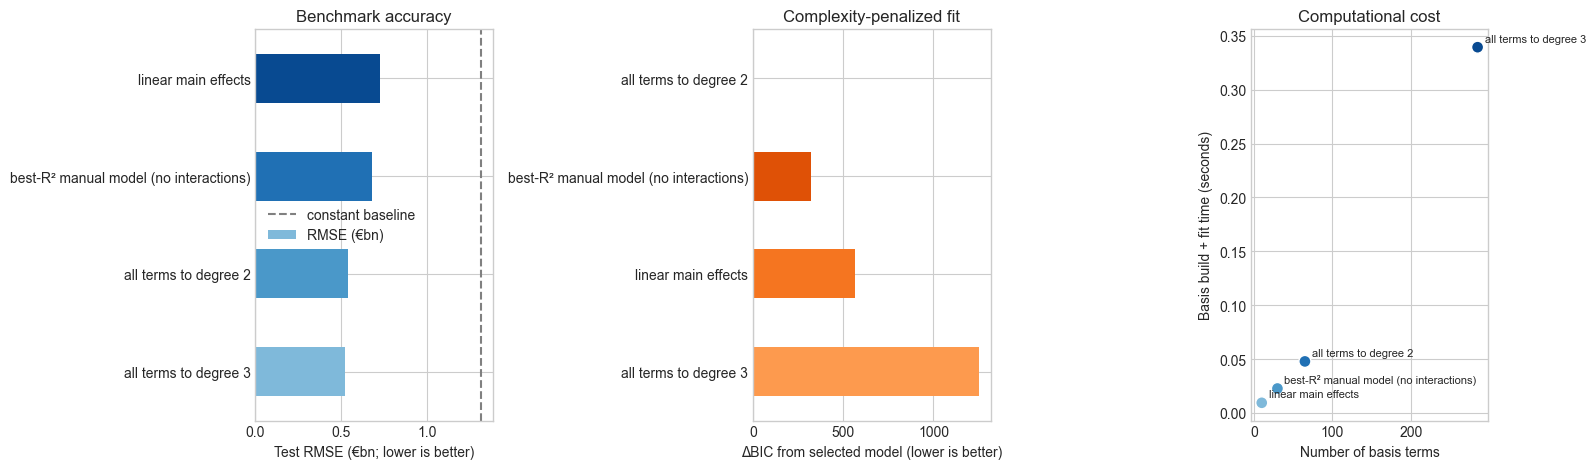

In [5]:
lab1.plot_model_comparison(comparison)


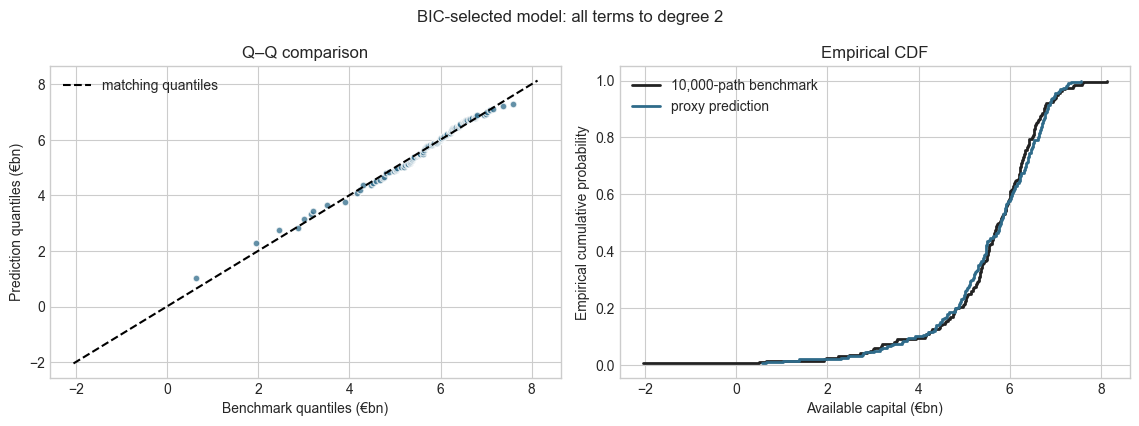

all terms to degree 2: R² = 0.834, ΔSCR = -0.251 €bn, fit time = 0.0375 s, BIC = -461.5.


In [6]:
lab1.plot_bic_selected_distribution(comparison)


## Debrief

Discuss with your neighbour:

1. Which hand-selected specification achieved the best $R^2$, and which achieved the lowest BIC?
2. How does $ΔSCR$ change when interactions are added? Does better average fit also improve the 99.5% percentile?
3. Where do the Q–Q plot and empirical CDF show the largest distributional differences?
4. Which exhaustive degree is selected by BIC, and why is the degree-3 model rejected despite its $R^2$?
5. How do basis size and fit time change when all degree-3 terms are added?
6. What subject-matter arguments could guide interaction selection in an internal model?
7. Why should this test benchmark not be reused indefinitely for model selection?
